
# *Initiate and Configure Spark*

---


In [ ]:
!pip3 install pyspark

In [ ]:
# linking with Spark
import  pyspark;
import pyspark.sql.functions as F;
from pyspark.sql import SparkSession;
from pyspark.sql.functions import col;
from pyspark.sql.types import StringType,IntegerType,BooleanType;

import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;

print(pyspark.__version__);

3.5.0


In [ ]:
spark = SparkSession \
        .builder \
        .appName("CRWK").getOrCreate();

# *Load Unstructured Data and Convert it to Spark DF [10 marks]*

---


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the unstructrued data: (1) drag and drop data here or (2) use Google Drive
with open('/content/drive/MyDrive/web.log','r') as file:
    r = file.read();

In [ ]:
import re;
pattern = r'(\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}) - - \[(\d{2}/[A-Za-z]{3}/\d{4}):(\d{2}:\d{2}:\d{2})\] "([A-Z]{0,8}) (\S+?) ([A-Z]+)/(\d.\d)" (\d{3}) (\d+) (.*)\.';

In [ ]:
x = re.findall(pattern,r);

In [ ]:
print(len(x));

3000000


In [ ]:
# create heading for the data
heading = ["_ip","_date","_time","_method","_url",
           "_protocol","_protocol_version","_status","_code","_message"];

In [ ]:
import os;
if not os.path.exists('/content/drive/MyDrive/output.csv'):
    import csv

    csv_file_path = "/content/drive/MyDrive/output.csv"

    with open(csv_file_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(heading)
        writer.writerows(x)

    print(f"CSV file created at: {csv_file_path}")

In [ ]:
# Convert the unstructrued data to Spark DF
df = spark.read.csv('/content/drive/MyDrive/output.csv',
                    header=True,
                    inferSchema=True);

In [ ]:
df.show();

+---------------+-----------+-------------------+-------+--------------------+---------+-----------------+-------+-----+--------------------+
|            _ip|      _date|              _time|_method|                _url|_protocol|_protocol_version|_status|_code|            _message|
+---------------+-----------+-------------------+-------+--------------------+---------+-----------------+-------+-----+--------------------+
| 88.211.105.115|04/Mar/2022|2023-11-21 14:17:48|   POST|  /history/missions/|     HTTP|              2.0|    414|12456|Caution: System m...|
|   144.6.49.142|02/Sep/2022|2023-11-21 15:16:00|   POST| /security/firewall/|    HTTPS|              1.0|    203|97126|Warning: Unusual ...|
|  231.70.64.145|19/Jul/2022|2023-11-21 01:31:31|    PUT|/web-development/...|     HTTP|              1.0|    201|33093|Informational mes...|
| 219.42.234.172|08/Feb/2022|2023-11-21 11:34:57|   POST|/networking/techn...|     HTTP|              1.0|    415|68827|Debug: Detailed s...|
| 183.


# *Task 1: Spark SQL [30 marks]*

---



+-----------+-----+
|_date_month|count|
+-----------+-----+
|        Oct| 1099|
|        Sep| 1155|
|        Dec| 1147|
|        Aug| 1068|
|        May| 1171|
|        Jun| 1123|
|        Feb| 1040|
|        Nov| 1146|
|        Mar| 1145|
|        Jan| 1154|
|        Apr| 1113|
|        Jul| 1124|
+-----------+-----+



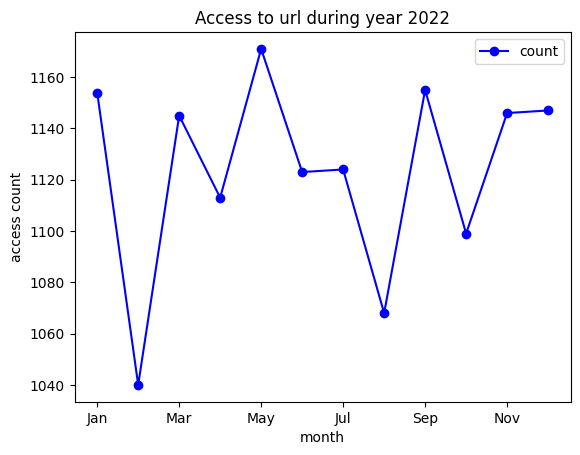

In [ ]:
# Query 1 [url : '/history/missions/' access over the year]:

@F.udf(StringType())
def extract_month(date):
    return date.split("/")[1];

@F.udf(StringType())
def extract_year(date):
    return date.split("/")[2];

@F.udf(IntegerType())
def month_to_int(month):
    li = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'];
    return li.index(month.lower());

history_url = df.filter(df['_url']=="/history/missions/") \
.withColumn("_date_year",extract_year(df["_date"])) ;

history_url = history_url.filter(col("_date_year") == '2022') \
.withColumn("_date_month",extract_month(df["_date"]));

history_url = history_url.groupBy(col("_date_month")) \
.count();

history_url.show();

history_url = history_url \
.withColumn("month",month_to_int(col("_date_month"))) \
.orderBy(col("month"));

history_url_pd = history_url.toPandas();
history_url_pd.plot(kind="line",
                    x="_date_month",
                    y='count',
                    marker='o',
                    linestyle='-',
                    color='b');
plt.xlabel('month');
plt.ylabel('access count');
plt.title("Access to url during year 2022");
plt.show();

+-----+-------+
|_date|  count|
+-----+-------+
| 2022|1606680|
| 2023|1393320|
+-----+-------+



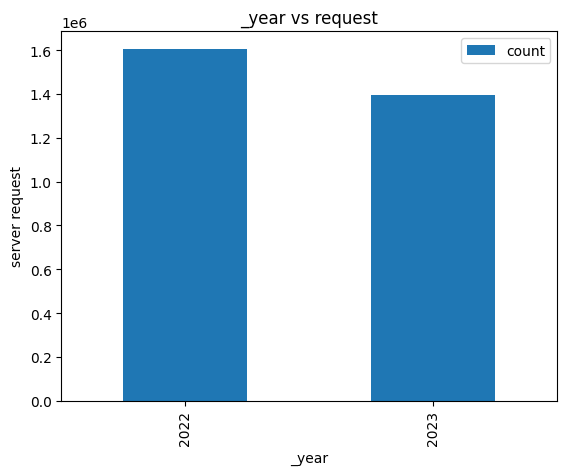

In [ ]:
# Query 2 [Server access in 2022 & 2023]:

@F.udf(StringType())
def dateToYear(date):
    return date.split("/")[2];

server_access = df.withColumn("_date",dateToYear(df["_date"])) \
                  .groupBy("_date") \
                  .count() \
                  .orderBy("_date");

server_access.show();

server_access_pd = server_access.toPandas();

server_access_pd.plot(kind="bar",x="_date",y="count");
plt.xlabel("_year");
plt.ylabel("server request");
plt.title("_year vs request");

plt.show();

+--------------------+-----+
|                _url|count|
+--------------------+-----+
|     /software/data/| 2996|
|/networking/missi...| 2897|
|/history/aws-cert...| 2890|
|/cloud-computing/...| 2880|
|/data-analysis/ap...| 2879|
+--------------------+-----+



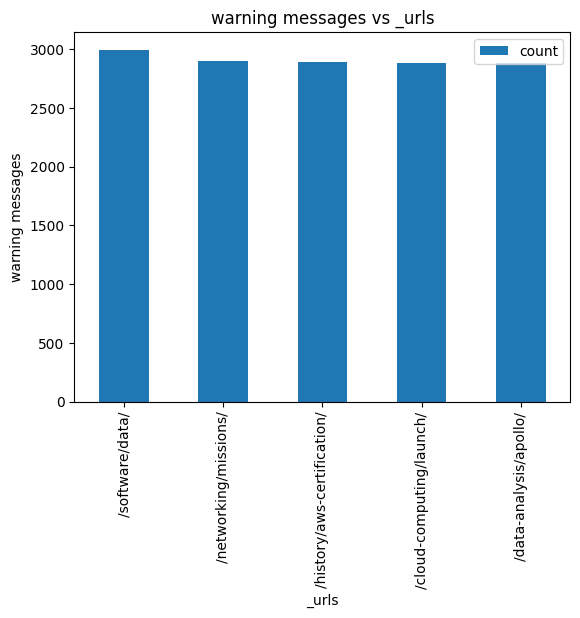

In [ ]:
# Query 1 [top-5 url having highest warning message]:

@F.udf(BooleanType())
def isStartWithWarning(message):
    return message.lower().startswith("warning");

warning = df.filter(isStartWithWarning(df["_message"])) \
.groupBy("_url").count().orderBy(col("count").desc()).limit(5);

warning.show();

warning_pd = warning.toPandas();

warning_pd.plot(kind="bar",x="_url",y="count");
plt.xlabel("_urls");
plt.ylabel("warning messages");
plt.title("warning messages vs _urls");

plt.show();

+---------+-------+
|  _status|  count|
+---------+-------+
|  SUCCESS|1286194|
|UNSUCCESS| 857598|
+---------+-------+



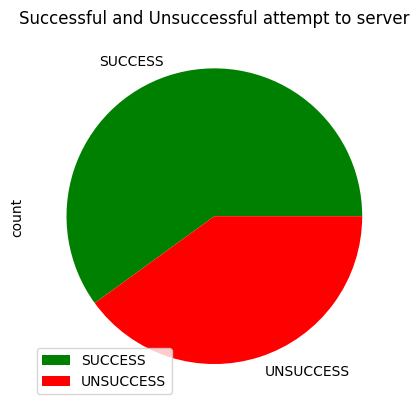

In [ ]:
# Query 2 [number of success & unsuccess attempt to sever]:

@F.udf(BooleanType())
def successAndUnsuccessAttemptIdentification(code):
    return str(code).startswith("2") or str(code).startswith("4")


@F.udf(StringType())
def codeToString(code):
    return "SUCCESS" if str(code).startswith("2") else "UNSUCCESS";

attempt = df.filter(successAndUnsuccessAttemptIdentification(df["_status"])) \
.withColumn("_status",codeToString(df["_status"])) \
.groupBy("_status").count().orderBy("_status");

attempt.show();

attempt_pd = attempt.toPandas();
attempt_pd.plot(kind="pie",y="count",labels=attempt_pd['_status'],colors=['green','red']);
plt.title("Successful and Unsuccessful attempt to server");
plt.legend();
plt.show();

In [ ]:
# Query 1 [urls and its suppoted methods]:

@F.udf(StringType())
def join(data):
    buffer = [];
    for _ in data.split("|"):
        if _ not in buffer:
            buffer.append(_);
    return "|".join(sorted(buffer));

urls_supported_methods = \
    df.groupBy("_url") \
    .agg(join(F.concat_ws("|",F.collect_list("_method")))
    .alias("Supported Methods"));

urls_supported_methods.show();

+--------------------+-----------------+
|                _url|Supported Methods|
+--------------------+-----------------+
|/web-development/...|     GET|POST|PUT|
|   /security/apollo/|     GET|POST|PUT|
|      /history/data/|     GET|POST|PUT|
|/history/technology/|     GET|POST|PUT|
|/data-analysis/aw...|     GET|POST|PUT|
|/cloud-computing/...|     GET|POST|PUT|
|/shuttle/frontend...|     GET|POST|PUT|
|    /history/launch/|     GET|POST|PUT|
|/software/apollo-11/|     GET|POST|PUT|
|/data-analysis/fr...|     GET|POST|PUT|
|/networking/front...|     GET|POST|PUT|
|   /security/launch/|     GET|POST|PUT|
|/machine-learning...|     GET|POST|PUT|
|/security/countdown/|     GET|POST|PUT|
|     /security/data/|     GET|POST|PUT|
|/networking/count...|     GET|POST|PUT|
|/web-development/...|     GET|POST|PUT|
|/networking/aws-c...|     GET|POST|PUT|
|  /shuttle/missions/|     GET|POST|PUT|
|      /shuttle/data/|     GET|POST|PUT|
+--------------------+-----------------+
only showing top

+-----+-----+
|_time|count|
+-----+-----+
|   AM|12637|
|   PM|12529|
+-----+-----+



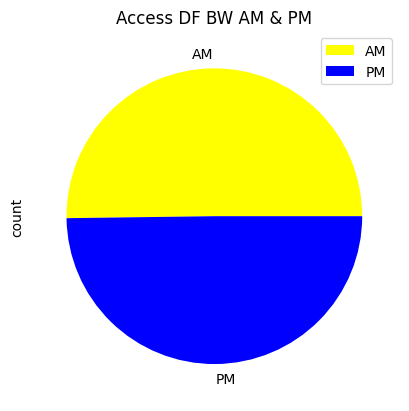

In [ ]:
# Query 2 [access difference in AM & PM at /history/missions/]:

def isAM(time):
    hh,mm,ss = time.split(":");
    hh,mm,ss = int(hh),int(mm),int(ss);
    return True if hh<12 or (hh == 12 and mm == 0 and ss == 0) else False;

@F.udf(StringType())
def timeToMeridiem(time):
    time = str(time).split(" ")[1];
    return "AM" if isAM(time) else "PM";

access_at_url = df.filter(df["_url"] == "/history/missions/") \
.withColumn("_time",timeToMeridiem(df["_time"])) \
.groupBy("_time") \
.count() \
.orderBy("_time");

access_at_url.show();

access_at_url = access_at_url.toPandas();
access_at_url.plot(kind="pie",y="count",labels=access_at_url['_time'],colors=['yellow','blue']);
plt.title("Access DF BW AM & PM");
plt.legend();
plt.show();


# *Task 2 - Spark RDD [50 marks]*

---


In [ ]:
csv_rdd = spark.sparkContext.textFile("/content/drive/MyDrive/output.csv");
parsed_rdd = csv_rdd.map(lambda line:line.split(","));

In [ ]:
heading_index = {var:idx for idx,var in
                 enumerate(parsed_rdd.first())};
print(heading_index);

{'_ip': 0, '_date': 1, '_time': 2, '_method': 3, '_url': 4, '_protocol': 5, '_protocol_version': 6, '_status': 7, '_code': 8, '_message': 9}


In [ ]:
# analysis 1 and result using RDD operators: number of unique IPs

number_of_unique_ip = parsed_rdd.map(
    lambda row: (row[heading_index['_ip']],1)
).reduceByKey(
    lambda x,y: (x+y)
).count();

print(f"number of unique ip : {number_of_unique_ip}");

number of unique ip : 2998935


('/data-analysis/apollo/', ('HTTP', 16912), ('HTTPS', 8528))
('/software/data/', ('HTTP', 16955), ('HTTPS', 8427))
('/web-development/missions/', ('HTTP', 16946), ('HTTPS', 8397))
('/history/countdown/', ('HTTP', 16837), ('HTTPS', 8501))
('/software/technology/', ('HTTP', 16928), ('HTTPS', 8399))


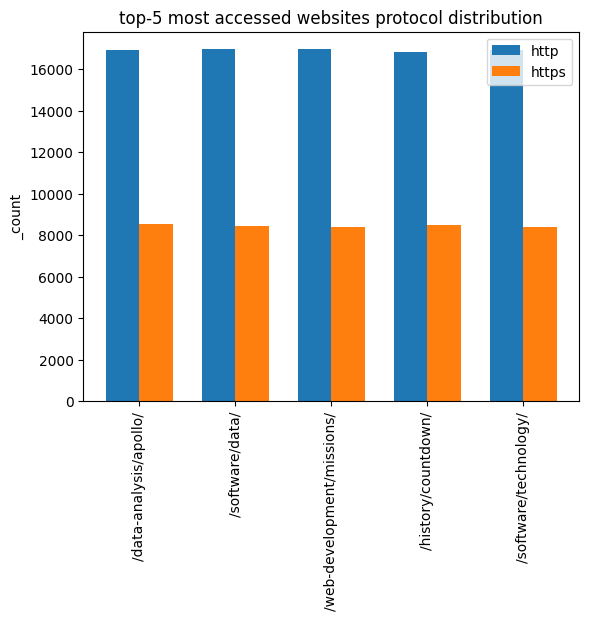

In [ ]:
# analysis 2 and result using RDD operators: top-5 most accessed website; counting different protocol used to access it;

protocol_count_of_top_5 = parsed_rdd.zipWithIndex().filter(
    lambda row: row[1] > 0
).map(
    lambda row: row[0]
).map(
    lambda row: ((row[heading_index['_url']],
                 row[heading_index['_protocol']]),1)
).reduceByKey(
    lambda x,y: x+y
).map(
    lambda row: (row[0][0],(row[0][1],row[1]))
).reduceByKey(
    lambda x,y: ((x[0],x[1]),(y[0],y[1]))
).map(
    lambda row: (row[0],
     ('HTTP',row[1][0][1] if row[1][0][0] == 'HTTP' else row[1][1][1]),
     ('HTTPS',row[1][0][1] if row[1][0][0] == 'HTTPS' else row[1][1][1]))
).sortBy(
    lambda row:row[1][1] + row[2][1], ascending=False
).take(5);

for _ in protocol_count_of_top_5:
    print(_);

x = protocol_count_of_top_5;
categories = [_[0] for _ in x];
http = [_[1][1] for _ in x];
https = [_[2][1] for _ in x];

bar_width = 0.35;
fig,ax = plt.subplots();

bar_position_http = np.arange(len(categories));
bar_position_https = [_ + bar_width
                      for _ in bar_position_http];


bar_http = ax.bar(bar_position_http,
              http,bar_width,label="http");
bar_https = ax.bar(bar_position_https,
                   https,bar_width,label="https");

ax.set_ylabel("_count");
ax.set_title('top-5 most accessed websites protocol distribution')
ax.set_xticks(bar_position_http + bar_width / 2);
ax.set_xticklabels(categories,rotation='vertical');
ax.legend();
plt.show();


In [ ]:
# analysis 3 and result using RDD operators: number of time particular url hit

url_hit = parsed_rdd.map(
    lambda row: (row[heading_index['_url']],1)
).reduceByKey(
    lambda x,y: (x+y)
).sortBy(
    lambda x: x[1],ascending=False
);

for _ in url_hit.collect():
    print(_);

('/data-analysis/apollo/', 25440)
('/software/data/', 25382)
('/web-development/missions/', 25343)
('/history/countdown/', 25338)
('/software/technology/', 25327)
('/security/technology/', 25307)
('/networking/deep-learning/', 25300)
('/networking/firewall/', 25249)
('/security/countdown/', 25239)
('/history/apollo/', 25238)
('/history/deep-learning/', 25223)
('/data-analysis/countdown/', 25212)
('/images/apollo-11/', 25211)
('/machine-learning/countdown/', 25188)
('/history/data/', 25186)
('/history/technology/', 25175)
('/data-analysis/frontend-frameworks-comparison/', 25174)
('/data-analysis/technology/', 25172)
('/web-development/deep-learning/', 25167)
('/history/missions/', 25166)
('/web-development/apollo-11/', 25162)
('/networking/missions/', 25157)
('/cloud-computing/missions/', 25154)
('/networking/countdown/', 25153)
('/images/apollo/', 25148)
('/data-analysis/cybersecurity/', 25142)
('/web-development/data/', 25139)
('/software/missions/', 25136)
('/shuttle/firewall/', 2513

('HTTP', 2000652)
('HTTPS', 999348)


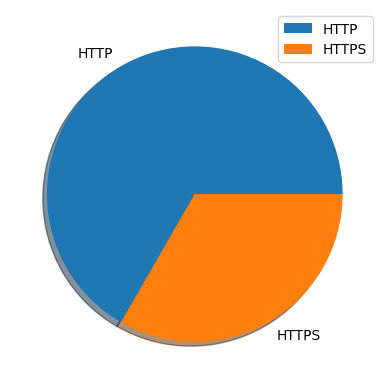

In [ ]:
# analysis 1 and result using RDD operators: number of time particular protocul used;

proto_used = parsed_rdd.zipWithIndex().filter(
    lambda row: row[1] > 0
).map(
    lambda row: row[0]
).map(
    lambda row: (row[heading_index['_protocol']],1)
).reduceByKey(
    lambda x,y: x+y
);

result = proto_used.collect();

for _ in result:
    print(_);

plt.pie([_[1] for _ in result],labels=[_[0] for _ in result],shadow=True);
plt.legend();
plt.show();

('POST', 1000505)
('PUT', 998452)
('GET', 1001043)


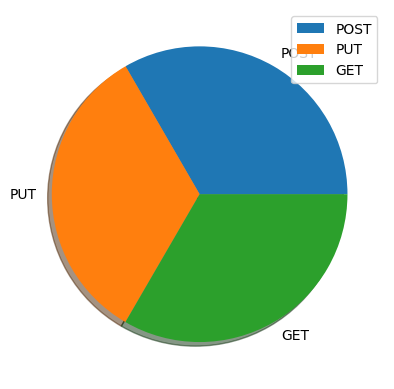

In [ ]:
# analysis 2 and result using RDD operators: number of different methods used in

method_count = parsed_rdd.zipWithIndex().filter(
    lambda row: row[1] > 0
).map(
    lambda row: row[0]
).map(
    lambda row: (row[heading_index['_method']],1)
).reduceByKey(
    lambda x,y: x+y
);

result = method_count.collect();

for _ in result:
    print(_)

plt.pie([_[1] for _ in result],labels=[_[0] for _ in result],shadow=True);
plt.legend();
plt.show();

('1.0', 1000084)
('2.0', 1000568)


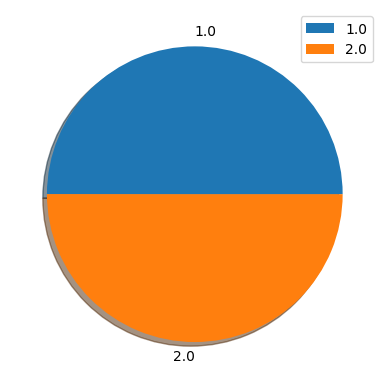

In [ ]:
# analysis 3 and result using RDD operators: different versoning count used in HTTP protocol

proto_count_in_http = parsed_rdd.zipWithIndex().filter(
    lambda row: row[1] > 0
).map(
    lambda row: row[0]
).filter(
    lambda row: row[heading_index['_protocol']] == 'HTTP'
).map(
    lambda row: (row[heading_index['_protocol_version']],1)
).reduceByKey(
    lambda x,y: x+y
);

result = proto_count_in_http.collect();

for _ in result:
    print(_);

plt.pie([_[1] for _ in result],labels=[_[0] for _ in result],shadow=True);
plt.legend();
plt.show();

('09/Sep/2022', 4604)
('11/Oct/2022', 4601)
('09/Jul/2022', 4592)
('06/May/2023', 4592)
('23/Jan/2022', 4581)


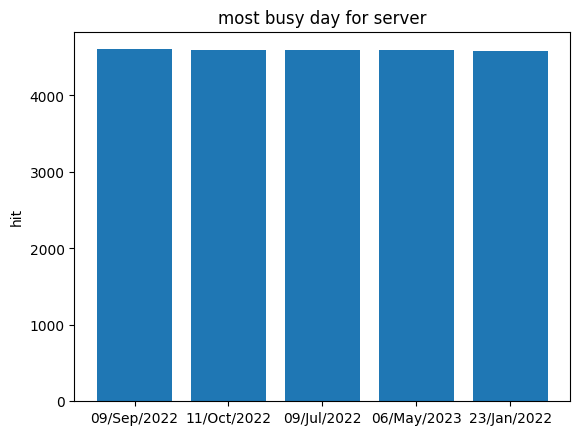

In [ ]:
# analysis 1 and result using RDD operators: most busy day(s) for server;

busy_days = parsed_rdd.zipWithIndex().filter(
    lambda row: row[1] > 0
).map(
    lambda row: row[0]
).map(
    lambda row: (row[heading_index['_date']],1)
).reduceByKey(
    lambda x,y: x+y
).takeOrdered(
    5,lambda row: -row[1]
);

for _ in busy_days:
    print(_);

categories = [_[0] for _ in busy_days];
values = [_[1] for _ in busy_days];

fig,ax = plt.subplots();
bar = ax.bar(categories,values);
ax.set_ylabel("hit");
ax.set_title("most busy day for server");
plt.show();

('415', 214135)
('414', 214705)
('404', 214584)
('416', 214174)


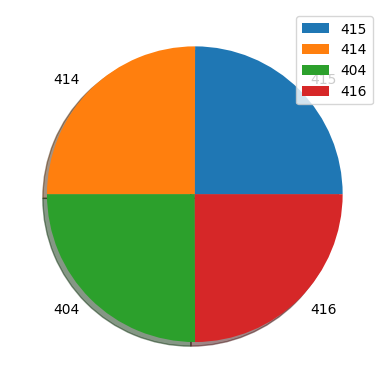

In [ ]:
# analysis 2 and result using RDD operators: counting number of bad requests;

bad_request_count = parsed_rdd.zipWithIndex().filter(
    lambda row: row[1] > 0
).map(
    lambda row: row[0]
).filter(
    lambda row: row[heading_index['_status']].startswith('4')
).map(
    lambda row: (row[heading_index['_status']],1)
).reduceByKey(
    lambda x,y: x+y
);

result = bad_request_count.collect();

for _ in result:
    print(_);

x = [_[1] for _ in result];
labels = [_[0] for _ in result];
plt.pie(x,labels=labels,shadow=True);
plt.legend();

[('61.203.220.155', 2), ('225.2.68.42', 2), ('189.15.120.110', 2), ('190.63.218.54', 2), ('18.133.225.189', 2)]


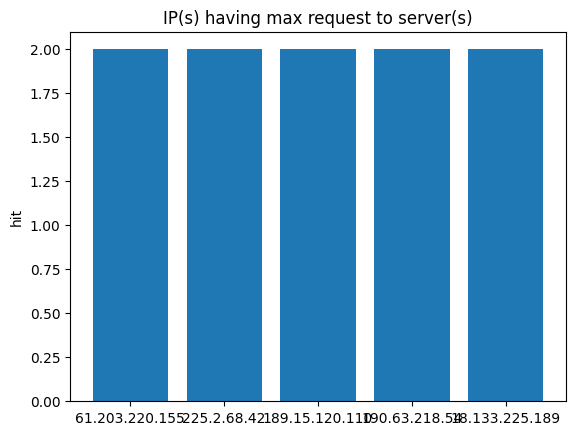

In [ ]:
# analysis 3 and result using RDD operators: max request from the IP(s);

ip_count = parsed_rdd.zipWithIndex().filter(
    lambda row: row[1] > 0
).map(
    lambda row: row[0]
).map(
    lambda row: (row[heading_index['_ip']],1)
).reduceByKey(
    lambda x,y: x+y
).takeOrdered(
    5,lambda row: -row[1]
);

print(ip_count);
categories = [_[0] for _ in ip_count];
values = [_[1] for _ in ip_count];

fig,ax = plt.subplots();
bar = ax.bar(categories,values);
ax.set_ylabel("hit");
ax.set_title("IP(s) having max request to server(s)");
plt.show();

In [3]:
# install nbconvert
# !pip3 install nbconvert


# convert ipynb to html
!jupyter nbconvert --to html '/content/drive/MyDrive/Colab Notebooks/49_CN7031.ipynb'

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/49_CN7031.ipynb to html
[NbConvertApp] Writing 1028514 bytes to /content/drive/MyDrive/Colab Notebooks/49_CN7031.html
